In [1]:
import os
import sys
import math
import random
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import torch
import torch.nn as nn
from torch.distributions.categorical import Categorical
from torch.distributions.normal import Normal
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import FlattenObservation, TransformAction
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

from rl_firm.abm.parameter import ModelParameters, FirmParameters, HouseholdParameters
from rl_firm.abm.firm import Firm, LearningFirm
from rl_firm.abm.household import Household
from rl_firm.abm.model import BaselineModel
from rl_firm.env import BaselineABMEnv, make_sb_env, make_custom_env, EVALUATION_SEEDS
from rl_firm.ppo_lstm_truncated import PPOAgent

In [3]:
def print_firm_info(firm):
    print(f'Class: {firm.__class__}')
    print(f'Status: {"Bankrupted" if firm.is_bankrupt else "Alive"}')
    print(f'Liquidity: {firm.liquidity}')
    print(f'Liquidity buffer: {firm.liquidity_buffer}')
    print(f'Inventory: {firm.inventories}')
    print(f'Wage rate: {firm.wage_rate}')
    print(f'Goods price: {firm.goods_price}')
    print(f'Employee count: {firm.employee_count}')
    print(f'Customer count: {firm.customer_count}')
    print(f'Last month demand: {firm.last_month_demand}')
    print(f'Last month revenue: {firm.last_month_revenue}')
    print(f'Last month profit: {firm.last_month_profit}')
    print(f'Profit ranking: {get_ranking(firm)}')

def load_model(seed):
    with open(f'../snapshots/abm_{seed}.pkl', 'rb') as f:
        print(f'Loading seed {seed}')
        return pickle.load(f)

## 1. Sim with more stats

In [5]:
def get_ranking(firm):
    return sorted(firm.model.firms,
                  key=lambda f: f.last_month_profit,
                  reverse=True).index(firm) + 1

def get_model_from_env(env):
    # Get the model from the wrapped model
    while True:
        if hasattr(env, '_model'):
            return env._model
        elif hasattr(env, 'env'):
            env = env.env
        else:
            raise Exception('Not ABM env')

In [6]:
MODEL_PATH = os.path.join(os.path.abspath(os.path.join('..')), 'results/model/lstm_truncated/2m_anneal.pt')
MODEL_PATH

'/Users/hieule/Projects/rl-firm-lengnick-abm/results/model/lstm_truncated/2m_anneal.pt'

In [7]:
def safe_div(num, denom):
    if denom is None or denom == 0 or np.isnan(denom):
        return np.nan
    return num / denom

def get_ranking(firm):
    return sorted(firm.model.firms,
                  key=lambda f: f.last_month_profit,
                  reverse=True).index(firm) + 1

def percentile_rank(a, x):
    a = np.asarray(a)
    if a.size == 0:
        raise ValueError("a must not be empty")
    below = np.sum(a < x)
    equal = np.sum(a == x)
    return 100.0 * (below + 0.5 * equal) / a.size

def simulate(years=100, seed=20):
    env = make_custom_env()()
    obs, info = env.reset(seed=seed)
    model = get_model_from_env(env)
    parameters = model.parameters
    learning_firm = model.learning_firms[0]
    stats = {
        # Firm stats
        'liquidity_buffers': [],
        'revenues': [],
        'profits': [],
        'rankings': [],
        'wage_rates': [],
        'goods_prices': [],
        'employee_counts': [],
        'customer_counts': [],
        'inventories': [],
        'last_month_demands': [],
        'months_since_hire_failure': [],
    
        # RL stats
        'wage_adjustments': [],
        'price_adjustments': [],
        'hr_actions': [],
        'rewards': [],
    
        # Analysis stats
        'marginal_costs': [],
        'price_markups': [],
        'inventory_to_demand': [],
        'price_percentiles': [],
        'wage_percentiles': [],
        'profit_percentiles': [],
        'employee_percentiles': [],
        'customer_percentiles': [],
        'median_active_prices': [],
        'median_active_wages': [],
        'median_active_profits': [],
        'median_active_employees': [],
        'median_active_customers': [],
        'median_active_inventories': [],
        'active_firm_counts': [],
    
        # New: learned-firm margin / scale tradeoff
        'profit_margins': [],
        'profit_per_employee': [],
        'revenue_per_employee': [],
    
        # New: market-level comparison
        'aggregate_active_revenues': [],
        'aggregate_active_profits': [],
        'aggregate_active_employees': [],
        'market_profit_margins': [],
        'market_profit_per_employee': [],
        'market_revenue_per_employee': [],
    
        # New: typical active-firm comparison
        'median_active_revenues': [],
        'median_active_profit_margins': [],
        'median_active_profit_per_employee': [],
        'median_active_revenue_per_employee': [],
    }
    
    
    def collect_stats(action, reward):
        stats['liquidity_buffers'].append(learning_firm.liquidity_buffer)
        stats['revenues'].append(learning_firm.last_month_revenue)
        stats['profits'].append(learning_firm.last_month_profit)
        stats['rankings'].append(get_ranking(learning_firm))
        stats['wage_rates'].append(learning_firm.wage_rate)
        stats['goods_prices'].append(learning_firm.goods_price)
        stats['employee_counts'].append(learning_firm.employee_count)
        stats['customer_counts'].append(learning_firm.customer_count)
        stats['inventories'].append(learning_firm.inventories)
        stats['last_month_demands'].append(learning_firm.last_month_demand)
        stats['months_since_hire_failure'].append(learning_firm.months_since_hire_failure)
    
        # RL stats
        if 'hr_action' in action:
            stats['hr_actions'].append(int(np.clip(np.round(action['hr_action']), 0, 2)))
            stats['price_adjustments'].append(action['price_adjustment'])
            stats['wage_adjustments'].append(action['wage_adjustment'])
        else:
            stats['hr_actions'].append(int(np.clip(np.round(action[0]), 0, 2)))
            stats['price_adjustments'].append(action[1])
            stats['wage_adjustments'].append(action[2])
    
        stats['rewards'].append(reward)
    
        # Learned-firm analysis stats
        stats['marginal_costs'].append(learning_firm.marginal_cost)
    
        stats['price_markups'].append(
            np.nan if learning_firm.marginal_cost <= 0
            else learning_firm.goods_price / learning_firm.marginal_cost
        )
    
        stats['inventory_to_demand'].append(
            np.nan if learning_firm.last_month_demand <= 0
            else learning_firm.inventories / learning_firm.last_month_demand
        )
    
        stats['profit_margins'].append(
            safe_div(learning_firm.last_month_profit, learning_firm.last_month_revenue)
        )
    
        stats['profit_per_employee'].append(
            safe_div(learning_firm.last_month_profit, learning_firm.employee_count)
        )
    
        stats['revenue_per_employee'].append(
            safe_div(learning_firm.last_month_revenue, learning_firm.employee_count)
        )
    
        # Active-firm market stats
        active_firms = model.firms.select(lambda f: not f.is_bankrupt)
    
        active_prices = np.asarray(active_firms.get('goods_price'), dtype=float)
        active_wages = np.asarray(active_firms.get('wage_rate'), dtype=float)
        active_profits = np.asarray(active_firms.get('last_month_profit'), dtype=float)
        active_revenues = np.asarray(active_firms.get('last_month_revenue'), dtype=float)
        active_employees = np.asarray(active_firms.get('employee_count'), dtype=float)
        active_customers = np.asarray(active_firms.get('customer_count'), dtype=float)
        active_inventories = np.asarray(active_firms.get('inventories'), dtype=float)
    
        # Percentiles
        stats['price_percentiles'].append(
            percentile_rank(active_prices, learning_firm.goods_price)
        )
        stats['wage_percentiles'].append(
            percentile_rank(active_wages, learning_firm.wage_rate)
        )
        stats['profit_percentiles'].append(
            percentile_rank(active_profits, learning_firm.last_month_profit)
        )
        stats['employee_percentiles'].append(
            percentile_rank(active_employees, learning_firm.employee_count)
        )
        stats['customer_percentiles'].append(
            percentile_rank(active_customers, learning_firm.customer_count)
        )
    
        # Existing median active-firm stats
        stats['median_active_prices'].append(np.nanmedian(active_prices))
        stats['median_active_wages'].append(np.nanmedian(active_wages))
        stats['median_active_profits'].append(np.nanmedian(active_profits))
        stats['median_active_employees'].append(np.nanmedian(active_employees))
        stats['median_active_customers'].append(np.nanmedian(active_customers))
        stats['median_active_inventories'].append(np.nanmedian(active_inventories))
        stats['active_firm_counts'].append(len(active_firms))
    
        # New aggregate market stats
        aggregate_active_revenue = np.nansum(active_revenues)
        aggregate_active_profit = np.nansum(active_profits)
        aggregate_active_employee = np.nansum(active_employees)
    
        stats['aggregate_active_revenues'].append(aggregate_active_revenue)
        stats['aggregate_active_profits'].append(aggregate_active_profit)
        stats['aggregate_active_employees'].append(aggregate_active_employee)
    
        stats['market_profit_margins'].append(
            safe_div(aggregate_active_profit, aggregate_active_revenue)
        )
    
        stats['market_profit_per_employee'].append(
            safe_div(aggregate_active_profit, aggregate_active_employee)
        )
    
        stats['market_revenue_per_employee'].append(
            safe_div(aggregate_active_revenue, aggregate_active_employee)
        )
    
        # New typical active-firm margin / productivity stats
        active_profit_margins = np.array([
            safe_div(p, r)
            for p, r in zip(active_profits, active_revenues)
        ])
    
        active_profit_per_employee = np.array([
            safe_div(p, e)
            for p, e in zip(active_profits, active_employees)
        ])
    
        active_revenue_per_employee = np.array([
            safe_div(r, e)
            for r, e in zip(active_revenues, active_employees)
        ])
    
        stats['median_active_revenues'].append(np.nanmedian(active_revenues))
        stats['median_active_profit_margins'].append(np.nanmedian(active_profit_margins))
        stats['median_active_profit_per_employee'].append(np.nanmedian(active_profit_per_employee))
        stats['median_active_revenue_per_employee'].append(np.nanmedian(active_revenue_per_employee))
        

    custom_lstm_agent = PPOAgent(obs_dim=int(np.array(env.observation_space.shape).prod()))
    custom_lstm_agent.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
    custom_lstm_agent.eval()
    
    lstm_state = (torch.zeros(custom_lstm_agent.lstm.num_layers, 1, custom_lstm_agent.lstm.hidden_size),
                  torch.zeros(custom_lstm_agent.lstm.num_layers, 1, custom_lstm_agent.lstm.hidden_size))
    done = torch.zeros(1)
    
    for _ in range(years * 12):
        action, lstm_state = custom_lstm_agent.predict(torch.Tensor(np.array([obs])), lstm_state, done, deterministic=True)
        action = {
            'hr_action': int(action['hr_action']),
            'price_adjustment': float(action['price_adjustment']),
            'wage_adjustment': float(action['wage_adjustment'])
        }
        obs, reward, terminated, truncated, _ = env.step(action)
        collect_stats(action, reward)
        done = torch.Tensor(np.array([terminated]))
        if terminated:
            print('Terminated! Went belly up')
            break
        if truncated:
            print('Truncated! Unprofitable')
            break
    
    print(f'Firm survived for {len(stats['profits']) // 12} years, making a total amount of {sum(stats['profits'])} of profit, with total reward {sum(stats['rewards'])}')

    return stats, model

In [8]:
%%time
stats, models = [], []
for seed in EVALUATION_SEEDS:
    stat, model = simulate(seed=seed)
    stats.append(stat)
    models.append(model)

Firm survived for 100 years, making a total amount of 65020094.11402316 of profit, with total reward 138.91633528570605
Firm survived for 100 years, making a total amount of 55175417.299739376 of profit, with total reward 118.11616984925463
Firm survived for 100 years, making a total amount of 41542866.86465268 of profit, with total reward 89.51898433212965
Firm survived for 100 years, making a total amount of 52525881.22511431 of profit, with total reward 113.00381235451312
Firm survived for 100 years, making a total amount of 54027779.66311136 of profit, with total reward 116.03194004525736
Terminated! Went belly up
Firm survived for 0 years, making a total amount of 0.0 of profit, with total reward 0.0
Firm survived for 100 years, making a total amount of 57673458.80354597 of profit, with total reward 123.11166911137624
Firm survived for 100 years, making a total amount of 51346811.39829166 of profit, with total reward 110.17939028232807
Terminated! Went belly up
Firm survived for 0

In [9]:
with open(os.path.join(os.path.abspath(os.path.join('..')), f'stats/interpretation_results.pkl'), "wb") as f:
    pickle.dump((stats, models), f)

## 2. Load stats

In [10]:
with open(os.path.join(os.path.abspath(os.path.join('..')), f'stats/interpretation_results.pkl'), "rb") as f:
    stats, _ = pickle.load(f)

In [11]:
TRANSIENT_CUTOFF = {20: 175, 21: 200, 22: 400, 23: 100, 24: 150,
                    26: 100, 27: 100, 29: 100,
                    30: None, 31: 100, 34: 100,
                    35: 75, 36: 150, 37: 75, 38: 125, 39: 225
}
STABLE_SEEDS = [20, 21, 22, 23, 24, 26, 27, 29, 31, 34, 35, 36, 37, 38, 39]

## 3. Anaylsis

### 3.1. Firm strategy

#### 3.1.1. Percentage of months with favorable relative positioning

In [12]:
def relative_position_summary(seed, start_month=None, end_month=None):
    stat = stats[seed-20]
    if start_month is None:
        start_month = TRANSIENT_CUTOFF[seed]
    learned_price = np.asarray(stat["goods_prices"], dtype=float)
    market_price = np.asarray(stat["median_active_prices"], dtype=float)

    learned_wage = np.asarray(stat["wage_rates"], dtype=float)
    market_wage = np.asarray(stat["median_active_wages"], dtype=float)

    if end_month is None:
        end_month = len(learned_price)

    sl = slice(start_month, end_month)

    lp = learned_price[sl]
    mp = market_price[sl]
    lw = learned_wage[sl]
    mw = market_wage[sl]

    price_gap_pct = 100 * (lp - mp) / mp
    wage_gap_pct = 100 * (lw - mw) / mw

    return pd.Series({
        "Share of months learned price below median (%)": 100 * np.mean(lp < mp),
        "Mean learned price gap vs median (%)": np.nanmean(price_gap_pct),
        "Median learned price gap vs median (%)": np.nanmedian(price_gap_pct),

        "Share of months learned wage above median (%)": 100 * np.mean(lw > mw),
        "Mean learned wage gap vs median (%)": np.nanmean(wage_gap_pct),
        "Median learned wage gap vs median (%)": np.nanmedian(wage_gap_pct),
    })

In [13]:
relative_position_summary(20)

Share of months learned price below median (%)     96.975610
Mean learned price gap vs median (%)               -0.920064
Median learned price gap vs median (%)             -0.860935
Share of months learned wage above median (%)     100.000000
Mean learned wage gap vs median (%)                 2.380504
Median learned wage gap vs median (%)               2.085406
dtype: float64

In [14]:
relative_position_summary(27)

Share of months learned price below median (%)    93.545455
Mean learned price gap vs median (%)              -1.471981
Median learned price gap vs median (%)            -1.419920
Share of months learned wage above median (%)     99.909091
Mean learned wage gap vs median (%)                2.808821
Median learned wage gap vs median (%)              2.621396
dtype: float64

#### 3.1.2. Relative-position stability

In [15]:
def relative_position_stability(seed, start_month=None, end_month=None):
    stat = stats[seed-20]
    if start_month is None:
        start_month = TRANSIENT_CUTOFF[seed]

    learned_price = np.asarray(stat["goods_prices"], dtype=float)
    market_price = np.asarray(stat["median_active_prices"], dtype=float)

    learned_wage = np.asarray(stat["wage_rates"], dtype=float)
    market_wage = np.asarray(stat["median_active_wages"], dtype=float)

    if end_month is None:
        end_month = len(learned_price)

    sl = slice(start_month, end_month)

    price_ratio = learned_price[sl] / market_price[sl]
    wage_ratio = learned_wage[sl] / market_wage[sl]

    return pd.Series({
        "Mean learned price / median price": np.nanmean(price_ratio),
        "Std. learned price / median price": np.nanstd(price_ratio, ddof=1),
        "Mean learned wage / median wage": np.nanmean(wage_ratio),
        "Std. learned wage / median wage": np.nanstd(wage_ratio, ddof=1),
    })

In [16]:
relative_position_stability(20)

Mean learned price / median price    0.990799
Std. learned price / median price    0.005564
Mean learned wage / median wage      1.023805
Std. learned wage / median wage      0.014148
dtype: float64

In [17]:
relative_position_stability(21)

Mean learned price / median price    0.986168
Std. learned price / median price    0.008535
Mean learned wage / median wage      1.023206
Std. learned wage / median wage      0.015057
dtype: float64

#### 3.1.3. Lag / co-movement analysis

In [18]:
def lag_correlation(
    seed,
    learned_key,
    market_key,
    start_month=None,
    end_month=None,
    max_lag=24,
    use_changes=True,
):
    stat = stats[seed-20]
    if start_month is None:
        start_month = TRANSIENT_CUTOFF[seed]
    
    learned = np.asarray(stat[learned_key], dtype=float)
    market = np.asarray(stat[market_key], dtype=float)

    if end_month is None:
        end_month = min(len(learned), len(market))

    learned = learned[start_month:end_month]
    market = market[start_month:end_month]

    if use_changes:
        learned = np.diff(learned)
        market = np.diff(market)

    rows = []

    for lag in range(-max_lag, max_lag + 1):
        if lag > 0:
            # market leads learned by lag months
            x = market[:-lag]
            y = learned[lag:]
        elif lag < 0:
            # learned leads market by abs(lag) months
            x = market[-lag:]
            y = learned[:lag]
        else:
            x = market
            y = learned

        if len(x) < 3 or np.nanstd(x) == 0 or np.nanstd(y) == 0:
            corr = np.nan
        else:
            corr = np.corrcoef(x, y)[0, 1]

        rows.append({
            "lag": lag,
            "correlation": corr,
            "interpretation": (
                "market leads learned" if lag > 0
                else "learned leads market" if lag < 0
                else "same month"
            )
        })

    return pd.DataFrame(rows)

In [19]:
price_lag_df = lag_correlation(
    20,
    learned_key="goods_prices",
    market_key="median_active_prices",
    max_lag=24,
    use_changes=True,
)

price_lag_df.sort_values("correlation", ascending=False).head(20)

,lag,correlation,interpretation
22,-2,0.163963,learned leads market
24,0,0.143205,same month
20,-4,0.140320,learned leads market
12,-12,0.139494,learned leads market
21,-3,0.135982,learned leads market
23,-1,0.133045,learned leads market
27,3,0.130564,market leads learned
28,4,0.125561,market leads learned
25,1,0.112664,market leads learned
0,-24,0.110166,learned leads market


In [20]:
wage_lag_df = lag_correlation(
    20,
    learned_key="wage_rates",
    market_key="median_active_wages",
    max_lag=24,
    use_changes=True,
)

wage_lag_df.sort_values("correlation", ascending=False).head(20)

,lag,correlation,interpretation
2,-22,0.101266,learned leads market
25,1,0.092438,market leads learned
43,19,0.090035,market leads learned
27,3,0.088408,market leads learned
46,22,0.077075,market leads learned
20,-4,0.074499,learned leads market
36,12,0.072943,market leads learned
39,15,0.071932,market leads learned
41,17,0.070940,market leads learned
45,21,0.070063,market leads learned


#### 3.1.4. Relative price/wage positioning

In [21]:
def learned_relative_position_summary(seed, start_month=None, end_month=None, price_switch_threshold=0.01):
    stat = stats[seed-20]
    if start_month is None:
        start_month = TRANSIENT_CUTOFF[seed]
        
    learned_price = np.asarray(stat["goods_prices"], dtype=float)
    median_price = np.asarray(stat["median_active_prices"], dtype=float)

    learned_wage = np.asarray(stat["wage_rates"], dtype=float)
    median_wage = np.asarray(stat["median_active_wages"], dtype=float)

    if end_month is None:
        end_month = len(learned_price)

    sl = slice(start_month, end_month)

    lp = learned_price[sl]
    mp = median_price[sl]
    lw = learned_wage[sl]
    mw = median_wage[sl]

    price_gap_pct = 100 * (lp - mp) / mp
    wage_gap_pct = 100 * (lw - mw) / mw

    return pd.Series({
        "Share months price below median (%)": 100 * np.mean(lp < mp),
        f"Share months price at least {price_switch_threshold:.0%} below median (%)": 100 * np.mean(lp <= (1 - price_switch_threshold) * mp),
        "Mean price gap vs median (%)": np.nanmean(price_gap_pct),
        "Median price gap vs median (%)": np.nanmedian(price_gap_pct),

        "Share months wage above median (%)": 100 * np.mean(lw > mw),
        "Mean wage gap vs median (%)": np.nanmean(wage_gap_pct),
        "Median wage gap vs median (%)": np.nanmedian(wage_gap_pct),
    })

In [22]:
learned_relative_position_summary(
    20,
    start_month=150,
    price_switch_threshold=0.01,
)

Share months price below median (%)                 96.285714
Share months price at least 1% below median (%)     38.095238
Mean price gap vs median (%)                        -0.912680
Median price gap vs median (%)                      -0.856082
Share months wage above median (%)                 100.000000
Mean wage gap vs median (%)                          2.479035
Median wage gap vs median (%)                        2.110161
dtype: float64

In [23]:
## Mean statistics across evaluation seeds
pd.concat([learned_relative_position_summary(
    seed,
    price_switch_threshold=0.01,
) for seed in STABLE_SEEDS], axis=1).mean(axis=1)

Share months price below median (%)                96.089013
Share months price at least 1% below median (%)    56.683609
Mean price gap vs median (%)                       -1.248959
Median price gap vs median (%)                     -1.152385
Share months wage above median (%)                 99.806157
Mean wage gap vs median (%)                         2.606783
Median wage gap vs median (%)                       2.076611
dtype: float64

In [24]:
def build_relative_gap_monthly_df(
    stats,
    end_month=None,
):
    rows = []
    
    for seed in STABLE_SEEDS:
        stat = stats[seed-20]
        start_month = TRANSIENT_CUTOFF[seed]

        learned_price = np.asarray(stat["goods_prices"], dtype=float)
        median_price = np.asarray(stat["median_active_prices"], dtype=float)

        learned_wage = np.asarray(stat["wage_rates"], dtype=float)
        median_wage = np.asarray(stat["median_active_wages"], dtype=float)

        n = min(
            len(learned_price),
            len(median_price),
            len(learned_wage),
            len(median_wage),
        )

        stop = n if end_month is None else min(end_month, n)

        for month in range(start_month, stop):
            if (
                median_price[month] <= 0
                or median_wage[month] <= 0
                or np.isnan(median_price[month])
                or np.isnan(median_wage[month])
            ):
                continue

            price_gap_pct = 100 * (
                learned_price[month] - median_price[month]
            ) / median_price[month]

            wage_gap_pct = 100 * (
                learned_wage[month] - median_wage[month]
            ) / median_wage[month]

            rows.append({
                "seed": seed,
                "month": month + 1,
                "price_gap_pct": price_gap_pct,
                "wage_gap_pct": wage_gap_pct,
                "price_below_median": price_gap_pct < 0,
                "price_at_least_1pct_below_median": price_gap_pct <= -1,
                "wage_above_median": wage_gap_pct > 0,
            })

    monthly_df = pd.DataFrame(rows)

    seed_summary_df = (
        monthly_df
        .groupby("seed", as_index=False)
        .agg(
            mean_price_gap_pct=("price_gap_pct", "mean"),
            mean_wage_gap_pct=("wage_gap_pct", "mean"),
            share_price_below_median=("price_below_median", "mean"),
            share_price_at_least_1pct_below_median=("price_at_least_1pct_below_median", "mean"),
            share_wage_above_median=("wage_above_median", "mean"),
        )
    )

    seed_summary_df["share_price_below_median"] *= 100
    seed_summary_df["share_price_at_least_1pct_below_median"] *= 100
    seed_summary_df["share_wage_above_median"] *= 100

    return monthly_df, seed_summary_df


def plot_relative_positioning_strategy(
    stats,
    end_month=None,
    price_switch_threshold=-1.0,
    suptitle="Learned firm relative positioning in goods and labor markets",
    download=False,
    filename="fig_relative_positioning_strategy.png",
):
    """
    Creates a two-panel figure:
    A. Seed-level positioning map.
    B. Distribution of monthly price/wage gaps.
    """

    monthly_df, seed_summary_df = build_relative_gap_monthly_df(
        stats=stats,
        end_month=end_month,
    )

    plt.rcdefaults()
    plt.rcParams.update({
        "figure.titlesize": 24,
        "axes.titlesize": 18,
        "axes.labelsize": 15,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
    })

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # ---------------- Panel A: positioning map ----------------
    ax = axes[0]

    sns.scatterplot(
        data=seed_summary_df,
        x="mean_price_gap_pct",
        y="mean_wage_gap_pct",
        s=90,
        ax=ax,
    )

    # Reference lines
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.axhline(0, linestyle="--", linewidth=1)
    
    # Optional: 1% cheaper threshold
    ax.axvline(-1, linestyle=":", linewidth=1)
    
    # Get axis limits for annotation placement
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    
    # Annotate x = 0 price parity line
    ax.annotate(
        "Median price",
        xy=(0, y_max-1),
        xytext=(-5, -10),
        textcoords="offset points",
        ha="right",
        va="top",
        fontsize=10,
        rotation=90,
    )
    
    # Annotate y = 0 wage parity line
    ax.annotate(
        "Median wage",
        xy=(x_max-0.2, 0),
        xytext=(-5, 5),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=10,
    )
    
    # Annotate 1% price advantage threshold
    ax.annotate(
        "1% price advantage",
        xy=(-1, y_max-1),
        xytext=(5, -10),
        textcoords="offset points",
        ha="left",
        va="top",
        fontsize=10,
        rotation=90,
    )
    ax.set_xlim(-2.2, 0.5)
    ax.set_ylim(-0.5, 3.5)
    ax.axvspan(-2.2, 0, ymin=(0 - (-0.5)) / (3.5 - (-0.5)), ymax=1, alpha=0.08)

    ax.set_title("Seed-level average market position")
    ax.set_xlabel("Mean price gap relative to market price (%)")
    ax.set_ylabel("Mean wage gap relative to market wage (%)")

    ax.text(
        0.02,
        0.98,
        "Lower price\nHigher wage",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
    )

    # ---------------- Panel B: distribution ----------------
    ax = axes[1]

    long_gap_df = pd.concat(
        [
            monthly_df[["seed", "month", "price_gap_pct"]]
            .rename(columns={"price_gap_pct": "gap_pct"})
            .assign(metric="Price gap"),

            monthly_df[["seed", "month", "wage_gap_pct"]]
            .rename(columns={"wage_gap_pct": "gap_pct"})
            .assign(metric="Wage gap"),
        ],
        ignore_index=True,
    )

    sns.kdeplot(
        data=long_gap_df,
        x="gap_pct",
        hue="metric",
        fill=True,
        common_norm=False,
        alpha=0.25,
        linewidth=1.5,
        ax=ax,
    )

    # Remove unnecessary legend title
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title(None)

    ax.axvline(0, linestyle="--", linewidth=1)
    ax.axvline(price_switch_threshold, linestyle=":", linewidth=1)

    ax.set_title("Monthly relative gap distribution")
    ax.set_xlabel("Gap relative to median active firm (%)")
    ax.set_ylabel("Density")

    fig.suptitle(suptitle, y=1.02)
    fig.tight_layout()

    if download:
        plt.savefig(f'../imgs/{filename}', dpi=300, bbox_inches="tight")

    plt.show()

    return monthly_df, seed_summary_df

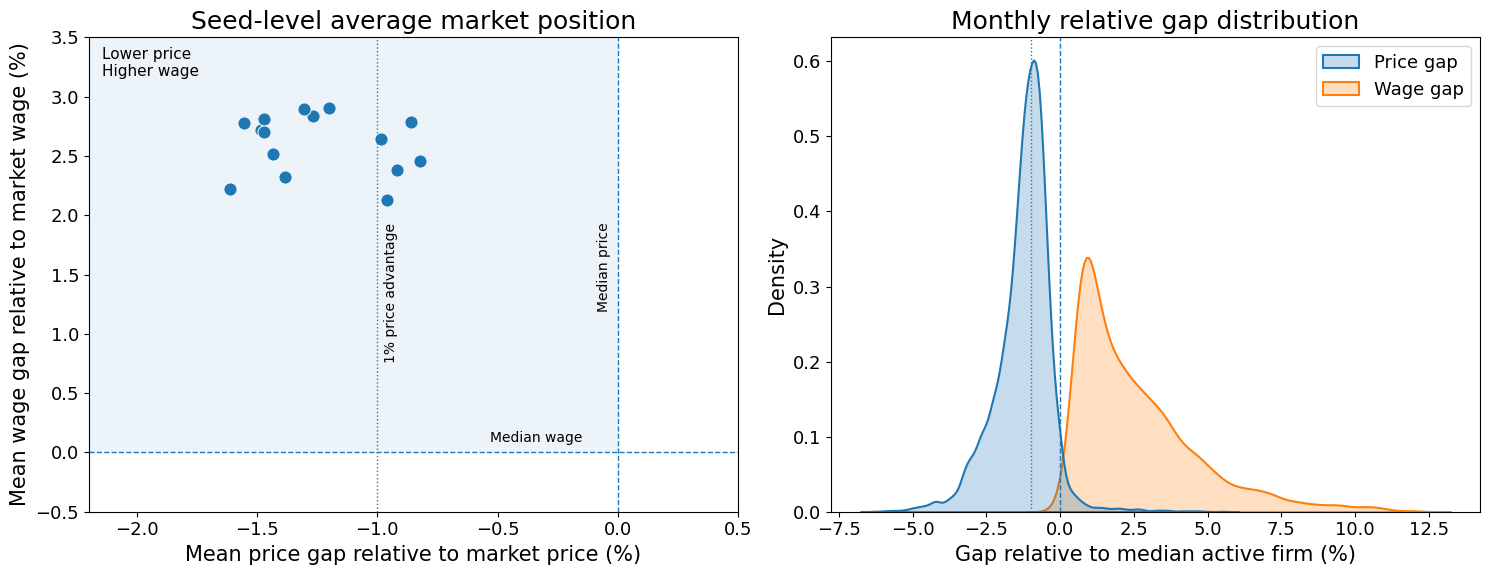

In [25]:
monthly_relative_df, seed_relative_df = plot_relative_positioning_strategy(
    stats=stats,
    price_switch_threshold=-1.0,
    download=True,
    suptitle=None,
    filename="fig_10.pdf",
)

#### 3.1.5. “Highest wage” / top-wage statistic

In [26]:
def learned_wage_rank_summary(seed, start_month=None, end_month=None):
    stat = stats[seed-20]
    if start_month is None:
        start_month = TRANSIENT_CUTOFF[seed]
    
    wage_pct = np.asarray(stat["wage_percentiles"], dtype=float)

    if end_month is None:
        end_month = len(wage_pct)

    wage_pct = wage_pct[start_month:end_month]

    return pd.Series({
        "Mean wage percentile": np.nanmean(wage_pct),
        "Share months wage in top 10% (%)": 100 * np.mean(wage_pct >= 90),
        "Share months wage in top 5% (%)": 100 * np.mean(wage_pct >= 95),
        "Share months wage in top 1% (%)": 100 * np.mean(wage_pct >= 99),
    })

learned_wage_rank_summary(20)

Mean wage percentile                93.026695
Share months wage in top 10% (%)    72.292683
Share months wage in top 5% (%)     49.756098
Share months wage in top 1% (%)     25.951220
dtype: float64

#### 3.1.6. Margin analysis

In [27]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec


def plot_trajectories_compare(
    stats_list,
    seed_labels=None,
    sections=None,
    metric_labels=None,
    marker=None,
    from_month=None,
    to_month=None,
    col_wrap=2,
    panel_height=4.0,
    aspect=2.0,

    # titles
    suptitle="Learning firm statistics by month across seeds",
    show_suptitle=True,
    show_section_titles=True,
    show_metric_titles=True,

    # transient annotations
    transient_points=None,          # shared points, drawn in black
    seed_transient_points=None,     # dict: seed label -> list of points, drawn in seed color
    show_transient_lines=True,
    shade_regions=False,
    region_colors=None,
    show_transient_note=False,

    # legend
    show_legend=True,

    # download
    download=False,
    filename="fig.png"
):
    if not stats_list:
        raise ValueError("stats_list must contain at least one stats dict.")

    metric_labels = metric_labels or {}

    if seed_labels is None:
        seed_labels = [f"Seed {i+1}" for i in range(len(stats_list))]

    if len(seed_labels) != len(stats_list):
        raise ValueError("seed_labels must have the same length as stats_list.")

    transient_points = sorted(transient_points or [])
    seed_transient_points = seed_transient_points or {}

    # ---------------- build long dataframe ----------------
    long_parts = []

    for seed_idx, stats in enumerate(stats_list):
        n = len(next(iter(stats.values())))
        months = list(range(1, n + 1))

        df = (
            pd.DataFrame(stats, index=months)
            .rename_axis("month")
            .reset_index()
            .melt(id_vars="month", var_name="metric", value_name="value")
        )
        df["seed"] = seed_labels[seed_idx]
        long_parts.append(df)

    long_df = pd.concat(long_parts, ignore_index=True)

    if from_month is not None:
        long_df = long_df[long_df["month"] >= from_month]

    if to_month is not None:
        long_df = long_df[long_df["month"] <= to_month]

    all_metrics = list(long_df["metric"].unique())

    if sections is None:
        sections = {"Metrics": all_metrics}
    else:
        sections = {
            title: [m for m in metrics if m in all_metrics]
            for title, metrics in sections.items()
        }
        sections = {title: metrics for title, metrics in sections.items() if metrics}

    if not sections:
        raise ValueError("No valid metrics found in sections.")

    # ---------------- style ----------------
    plt.rcdefaults()
    plt.rcParams.update({
        "figure.titlesize": 28,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 18,
    })

    palette = sns.color_palette(n_colors=len(seed_labels))
    seed_color_map = dict(zip(seed_labels, palette))

    # ---------------- layout bookkeeping ----------------
    section_specs = []
    total_plot_rows = 0
    max_cols = 0

    for section_title, metrics in sections.items():
        ncols = min(col_wrap, len(metrics))
        nrows = math.ceil(len(metrics) / ncols)
        section_specs.append((section_title, metrics, nrows, ncols))
        total_plot_rows += nrows
        max_cols = max(max_cols, ncols)

    title_row_count = len(section_specs) if show_section_titles else 0
    total_rows = total_plot_rows + title_row_count

    fig_width = max_cols * panel_height * aspect
    fig_height = total_plot_rows * panel_height + (0.55 * title_row_count) + 1.0

    fig = plt.figure(figsize=(fig_width, fig_height))

    if show_section_titles:
        height_ratios = [
            0.22 if row_is_title else 1.0
            for row_is_title in _title_row_mask(section_specs)
        ]
    else:
        height_ratios = [1.0] * total_rows

    gs = GridSpec(
        total_rows,
        max_cols,
        figure=fig,
        height_ratios=height_ratios
    )

    if show_suptitle:
        fig.suptitle(suptitle, y=0.995)

    x_min = long_df["month"].min()
    x_max = long_df["month"].max()

    if region_colors is None:
        region_colors = ["#dbeafe", "#f3f4f6"]

    def draw_shared_regions(ax):
        if not shade_regions or not transient_points:
            return

        bounds = [x_min] + [p for p in transient_points if x_min < p < x_max] + [x_max]
        for i in range(len(bounds) - 1):
            left = bounds[i]
            right = bounds[i + 1]
            color = region_colors[i % len(region_colors)]
            ax.axvspan(left, right, color=color, alpha=0.25, zorder=0)

    def draw_shared_transient_lines(ax):
        if not show_transient_lines:
            return

        for p in transient_points:
            if x_min <= p <= x_max:
                ax.axvline(
                    p,
                    color="black",
                    linestyle="--",
                    linewidth=0.9,
                    zorder=1
                )

    def draw_seed_transient_lines(ax):
        if not show_transient_lines:
            return

        for seed, points in seed_transient_points.items():
            color = seed_color_map.get(seed, "black")
            for p in points:
                if x_min <= p <= x_max:
                    ax.axvline(
                        p,
                        color=color,
                        linestyle="--",
                        linewidth=1.0,
                        alpha=0.9,
                        zorder=1
                    )

    # ---------------- draw ----------------
    current_row = 0
    first_ax = None
    legend_handles = None
    legend_labels = None

    for section_title, metrics, nrows, ncols in section_specs:
        if show_section_titles:
            title_ax = fig.add_subplot(gs[current_row, :])
            title_ax.axis("off")
            title_ax.text(
                0.5, 0.5, section_title,
                ha="center", va="center",
                fontsize=22
            )
            current_row += 1

        section_axes = []

        for i, metric in enumerate(metrics):
            r = i // ncols
            c = i % ncols

            ax = fig.add_subplot(
                gs[current_row + r, c],
                sharex=first_ax if first_ax is not None else None
            )

            if first_ax is None:
                first_ax = ax

            metric_df = long_df[long_df["metric"] == metric]

            draw_shared_regions(ax)
            draw_shared_transient_lines(ax)
            draw_seed_transient_lines(ax)

            sns.lineplot(
                data=metric_df,
                x="month",
                y="value",
                hue="seed",
                marker=marker,
                linewidth=1,
                ax=ax,
                legend=True,
                palette=seed_color_map,
            )

            handles, labels = ax.get_legend_handles_labels()
            if handles and labels and legend_handles is None:
                legend_handles, legend_labels = handles, labels
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

            display_name = metric_labels.get(metric, metric.replace("_", " ").title())
            if show_metric_titles:
                ax.set_title(display_name, pad=4)
            else:
                ax.set_title("")

            ax.set_ylabel("")
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

            section_axes.append(ax)

        for ax in section_axes[max(0, len(metrics) - ncols):]:
            ax.set_xlabel("month")
            ax.tick_params(axis="x", labelbottom=True)

        for j in range(len(metrics), nrows * ncols):
            r = j // ncols
            c = j % ncols
            blank_ax = fig.add_subplot(gs[current_row + r, c])
            blank_ax.axis("off")

        current_row += nrows

    if show_legend and legend_handles is not None:
        legend_y = 0.975 if show_suptitle else 0.995
        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            ncol=len(seed_labels),
            bbox_to_anchor=(0.5, legend_y),
            frameon=False,
        )

    if show_transient_note and (transient_points or seed_transient_points):
        note_parts = []

        if shade_regions and transient_points:
            note_parts.append("Alternating shaded regions indicate successive time regimes")

        if transient_points:
            if len(transient_points) == 1:
                note_parts.append(
                    f"black dashed line marks the shared transient point at month {transient_points[0]}"
                )
            else:
                points_str = ", ".join(str(p) for p in transient_points)
                note_parts.append(
                    f"black dashed lines mark shared transient points at months {points_str}"
                )

        if seed_transient_points:
            note_parts.append("colored dashed lines mark seed-specific transient points")

        note = ". ".join(note_parts) + "."
        fig.text(0.5, 0.01, note, ha="center", va="bottom", fontsize=9)
        top_rect = 0.94 if (show_suptitle or show_legend) else 0.985
        fig.tight_layout(rect=[0, 0.03, 1, top_rect])
    else:
        top_rect = 0.94 if (show_suptitle or show_legend) else 0.985
        fig.tight_layout(rect=[0, 0, 1, top_rect])

    if download:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def _title_row_mask(section_specs):
    mask = []
    for _, _, nrows, _ in section_specs:
        mask.append(True)
        mask.extend([False] * nrows)
    return mask

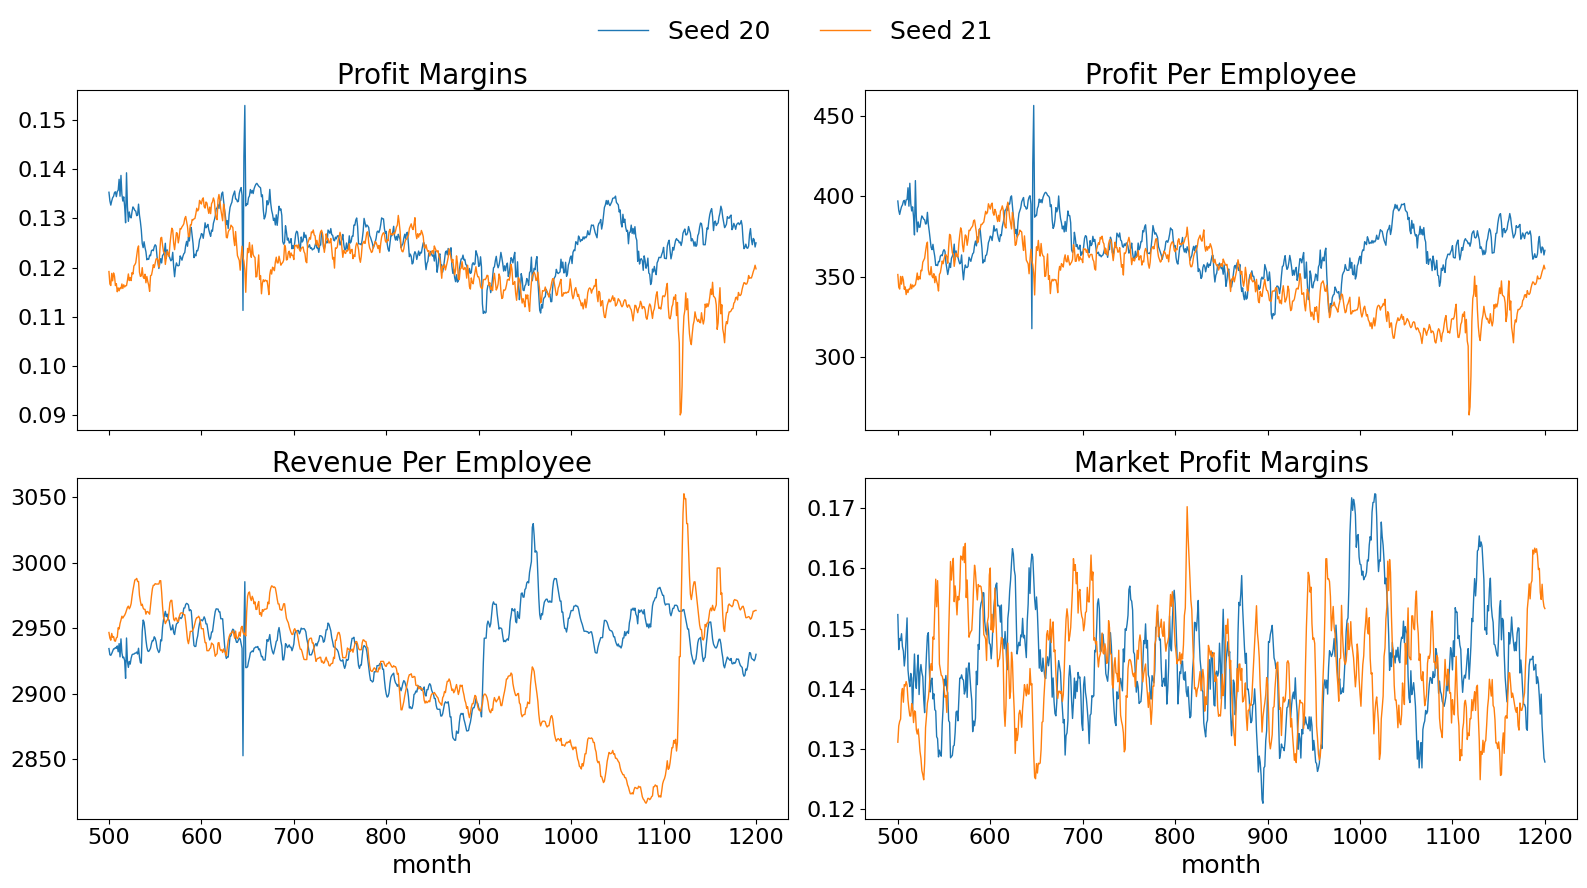

In [28]:
sections = {
    "State variables and outcome": [
        'profit_margins',
        'profit_per_employee',
        'revenue_per_employee',
        'market_profit_margins'
    ],
}

metric_labels = {
    "profit_percentiles": "Profit percentile among active firms",
    "liquidity_buffers": "Liquidity buffer",
    "goods_prices": "Goods price",
    "wage_rates": "Wage rate",
    "employee_counts": "Employee count",
    "customer_counts": "Customer count",
    "price_adjustments": "Price adjustment",
    "wage_adjustments": "Wage adjustment",
    "hr_actions": "HR action",
}

plot_trajectories_compare(
    stats_list=[stats[i-20] for i in [20, 21]],
    seed_labels=[f'Seed {i}' for i in [20, 21]],
    sections=sections,
    metric_labels=metric_labels,
    seed_transient_points={},
    show_suptitle=False,
    show_section_titles=False,
    download=False,
    filename="compare_all.png",
    from_month=500
)

In [29]:
def ratio_of_sums(numerator, denominator, start_month=0, end_month=None):
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)

    if end_month is None:
        end_month = min(len(numerator), len(denominator))

    numerator = numerator[start_month:end_month]
    denominator = denominator[start_month:end_month]

    total_denominator = np.nansum(denominator)

    if total_denominator == 0:
        return np.nan

    return np.nansum(numerator) / total_denominator


def summarize_margin_tradeoff(seed, start_month=None, end_month=None):
    stat = stats[seed-20]
    if start_month is None:
        start_month = TRANSIENT_CUTOFF[seed]
    return {
        "learned_profit_margin": ratio_of_sums(
            stat["profits"],
            stat["revenues"],
            start_month,
            end_month,
        ),
        "market_profit_margin": ratio_of_sums(
            stat["aggregate_active_profits"],
            stat["aggregate_active_revenues"],
            start_month,
            end_month,
        ),
        "learned_profit_per_employee_month": ratio_of_sums(
            stat["profits"],
            stat["employee_counts"],
            start_month,
            end_month,
        ),
        "market_profit_per_employee_month": ratio_of_sums(
            stat["aggregate_active_profits"],
            stat["aggregate_active_employees"],
            start_month,
            end_month,
        ),
        "learned_revenue_per_employee_month": ratio_of_sums(
            stat["revenues"],
            stat["employee_counts"],
            start_month,
            end_month,
        ),
        "market_revenue_per_employee_month": ratio_of_sums(
            stat["aggregate_active_revenues"],
            stat["aggregate_active_employees"],
            start_month,
            end_month,
        ),
    }

In [31]:
## Mean statistics across evaluation seeds
pd.concat([pd.Series(summarize_margin_tradeoff(seed))
           for seed in STABLE_SEEDS], axis=1).mean(axis=1)

learned_profit_margin                    0.121734
market_profit_margin                     0.146410
learned_profit_per_employee_month      355.940298
market_profit_per_employee_month       432.400846
learned_revenue_per_employee_month    2923.743947
market_revenue_per_employee_month     2953.386340
dtype: float64

In [32]:
1 - 355.940298 / 432.400846

0.1768279334032571